# 🚨 Incident Ops — SRE RL Agent Training

**Pipeline:** SFT warm-start → GRPO reinforcement learning  
**Model:** Qwen2.5-3B-Instruct (via Unsloth 4-bit, fits on T4)  
**Output:** `outputs/` — `reward_log.csv` + `reward_curve.png` + `model.pkl` saved to Google Drive

**Workflow:**
1. ✅ Setup — install deps, clone repo, mount Drive
2. ✅ Smoke test — verify env + reward functions (CPU, ~10s)
3. ✅ SFT warm-start — train on optimal trajectories (~5 min)
4. ✅ GRPO training — RL fine-tuning with 9 reward signals (~45–60 min)
5. ✅ Visualise — reward curve + component bars (inline)
6. ✅ Save — `model.pkl` + logs to Drive
7. ✅ Evaluate — before vs after score table (inline)

> **Runtime:** T4 GPU (free tier). Enable: Runtime → Change runtime type → GPU → T4

## 1️⃣  Setup

In [1]:
# Confirm GPU is available
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
if result.returncode == 0:
    print(f'✓ GPU: {result.stdout.strip()}')
else:
    print('⚠  No GPU detected — go to Runtime → Change runtime type → T4 GPU')

✓ GPU: Tesla T4, 15360 MiB


In [3]:
# Mount Google Drive — outputs will be saved here so they survive session end
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_OUTPUT = '/content/drive/MyDrive/incident_ops_outputs'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print(f'✓ Drive mounted — outputs → {DRIVE_OUTPUT}')

Mounted at /content/drive
✓ Drive mounted — outputs → /content/drive/MyDrive/incident_ops_outputs


In [4]:
%%capture install_log
# Install all dependencies (takes ~2-3 min on first run, cached after)
!pip install unsloth trl>=0.12 transformers>=4.45 datasets pydantic pyyaml fastapi uvicorn matplotlib pandas scipy

In [8]:
import os

REPO_URL = 'https://github.com/Christy-Saji/incident-ops-openenv.git'
REPO_DIR = '/content/incident-ops-openenv'

if os.path.exists(REPO_DIR):
    print('Repo already cloned — pulling latest...')
    os.system(f'git -C {REPO_DIR} pull --rebase')
else:
    os.system(f'git clone {REPO_URL} {REPO_DIR}')

os.chdir(REPO_DIR)
print(f'✓ Working directory: {os.getcwd()}')
print('Files:', os.listdir('.'))

Repo already cloned — pulling latest...
✓ Working directory: /content/incident-ops-openenv
Files: ['colab_training.ipynb', 'app.py', 'scripts', 'compare_inference.py', '.git', 'Dockerfile', 'pyproject.toml', 'env', '.gitignore', 'openenv.yaml', 'graders', 'train.py', 'config', 'static', 'tests', 'outputs', 'training', 'tasks', '.github', 'README.md', 'server']


In [9]:
# Create output directories
OUTPUT_DIR = '/content/incident-ops-openenv/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/sft',  exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/grpo', exist_ok=True)
print(f'✓ Output dirs ready under {OUTPUT_DIR}')

✓ Output dirs ready under /content/incident-ops-openenv/outputs


## 2️⃣  Smoke Test (CPU — ~10s)

In [10]:
import sys
sys.path.insert(0, REPO_DIR)

from env.environment import DevOpsEnv
from graders.grader import compute_score
from training.reward_functions import format_reward_func, anti_cheat_reward_func

# Test all 6 tasks
tasks = ['easy', 'medium', 'hard', 'network', 'memory_leak', 'disk_full']
for t in tasks:
    env = DevOpsEnv(task=t)
    obs = env.reset()
    _, r, done, _ = env.step('acknowledge_incident')
    score, _ = compute_score(t, env._state)
    print(f'  {t:12s}  step_reward={r:.3f}  score={score:.3f}  done={done}')

dummy_completions = [
    [{"role": "assistant", "content": "acknowledge_incident"}],
    [{"role": "assistant", "content": "no_op"}],
    [{"role": "assistant", "content": "inspect_auth_logs"}],
]
fmt = format_reward_func(None, dummy_completions)

print(f'\nformat_reward_func output: {fmt}')
print('\n✓ All smoke tests passed')

  easy          step_reward=0.050  score=0.260  done=False
  medium        step_reward=0.080  score=0.270  done=False
  hard          step_reward=0.090  score=0.160  done=False
  network       step_reward=0.080  score=0.240  done=False
  memory_leak   step_reward=0.050  score=0.240  done=False
  disk_full     step_reward=0.050  score=0.260  done=False

format_reward_func output: [0.1, 0.1, 0.1]

✓ All smoke tests passed


## 3️⃣  Load Model (Unsloth 4-bit)

In [11]:
from unsloth import FastLanguageModel
import torch

MODEL_ID    = 'unsloth/Qwen2.5-3B-Instruct'   # best quality/VRAM tradeoff on T4
MAX_SEQ_LEN = 1024
LORA_RANK   = 32
LORA_ALPHA  = 16

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = MAX_SEQ_LEN,
    dtype          = None,   # auto-detect
    load_in_4bit   = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r              = LORA_RANK,
    lora_alpha     = LORA_ALPHA,
    target_modules = ['q_proj','k_proj','v_proj','o_proj',
                      'gate_proj','up_proj','down_proj'],
    lora_dropout   = 0.05,
    bias           = 'none',
    use_gradient_checkpointing = 'unsloth',
    random_state   = 42,
)

print(f'✓ Model loaded: {MODEL_ID}')
print(f'  Parameters: {model.num_parameters():,}')
print(f'  Trainable:  {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.2 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✓ Model loaded: unsloth/Qwen2.5-3B-Instruct
  Parameters: 3,145,805,824
  Trainable:  59,867,136


## 4️⃣  SFT Warm-Start (~5 min)

In [12]:
from training.dataset import generate_sft_dataset
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

# Build SFT dataset from optimal trajectories (no tokenizer arg needed)
sft_dataset = generate_sft_dataset(seed=42)
print(f'SFT dataset: {len(sft_dataset)} examples')

def format_sample(example):
    messages = example['prompt'] + example['completion']
    return {'text': tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )}

sft_dataset = sft_dataset.map(format_sample)

sft_trainer = SFTTrainer(
    model     = model,
    tokenizer = tokenizer,
    train_dataset = sft_dataset,
    args = SFTConfig(
        output_dir           = f'{OUTPUT_DIR}/sft',
        num_train_epochs     = 2,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps         = 5,
        learning_rate        = 2e-4,
        fp16                 = not is_bfloat16_supported(),
        bf16                 = is_bfloat16_supported(),
        logging_steps        = 5,
        save_strategy        = 'no',
        report_to            = 'none',
        seed                 = 42,
        dataset_text_field   = 'text',
        max_seq_length       = MAX_SEQ_LEN,
    ),
)

print('Starting SFT warm-start...')
sft_trainer.train()
print('SFT warm-start complete')


  [dataset] SFT: 41 (state, optimal_action) pairs across 6 tasks.
SFT dataset: 41 examples


Map:   0%|          | 0/41 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=6):   0%|          | 0/41 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Starting SFT warm-start...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 41 | Num Epochs = 2 | Total steps = 12
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
5,1.139528
10,0.502947


SFT warm-start complete


## 5️⃣  GRPO Training (~45–60 min)

In [13]:
# GRPO hyperparameters -- edit these if needed
GRPO_MAX_STEPS  = 300   # ~60 min on T4; set to 50-100 for a quick test run
NUM_GENERATIONS = 8     # rollouts per prompt -- keep at 8 for Qwen 3B on T4
GRPO_LR         = 5e-6
SAVE_STEPS      = 50    # checkpoint every 50 steps (auto-resume if Colab disconnects)

print(f'GRPO: {GRPO_MAX_STEPS} steps | {NUM_GENERATIONS} generations | lr={GRPO_LR}')
print(f'Checkpoints every {SAVE_STEPS} steps -> {OUTPUT_DIR}/grpo/')


GRPO: 300 steps | 8 generations | lr=5e-06
Checkpoints every 50 steps -> /content/incident-ops-openenv/outputs/grpo/


In [14]:
from trl import GRPOTrainer, GRPOConfig
from training.callbacks import RewardLoggerCallback
from training.dataset import generate_grpo_dataset
from training.reward_functions import ALL_REWARD_FUNCTIONS
from unsloth import is_bfloat16_supported
import os

LOG_CSV = f'{OUTPUT_DIR}/reward_log.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

grpo_dataset = generate_grpo_dataset(
    per_task_n    = 8,
    mid_episode_n = 60,
    seed          = 42,
)
print(f'GRPO dataset: {len(grpo_dataset)} prompts')

grpo_args = GRPOConfig(
    output_dir                  = f'{OUTPUT_DIR}/grpo',
    learning_rate               = GRPO_LR,
    lr_scheduler_type           = 'cosine',
    warmup_steps                = 8,
    max_steps                   = GRPO_MAX_STEPS,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    num_generations             = NUM_GENERATIONS,
    max_prompt_length           = 1024,
    max_completion_length       = 32,
    temperature                 = 0.9,
    max_grad_norm               = 0.3,
    fp16                        = not is_bfloat16_supported(),
    bf16                        = is_bfloat16_supported(),
    logging_steps               = 1,
    save_steps                  = SAVE_STEPS,
    save_total_limit            = 3,   # keep latest 3 checkpoints only
    report_to                   = 'none',
)

reward_logger = RewardLoggerCallback(log_path=LOG_CSV)

trainer = GRPOTrainer(
    model            = model,
    processing_class = tokenizer,
    reward_funcs     = ALL_REWARD_FUNCTIONS,
    args             = grpo_args,
    train_dataset    = grpo_dataset,
    callbacks        = [reward_logger],
)

# Auto-resume from latest checkpoint if Colab disconnected mid-training
def _latest_ckpt(d):
    import os
    if not os.path.isdir(d): return None
    ckpts = sorted(
        [x for x in os.listdir(d) if x.startswith('checkpoint-')],
        key=lambda x: int(x.split('-')[-1])
    )
    return os.path.join(d, ckpts[-1]) if ckpts else None

resume = _latest_ckpt(f'{OUTPUT_DIR}/grpo')
if resume:
    print(f'Resuming from {resume}')
else:
    print('Starting fresh GRPO run...')

trainer.train(resume_from_checkpoint=resume)
print('GRPO training complete')


  [dataset] GRPO: 108 prompts (8/task × 6 tasks + 60 mid-episode).
GRPO dataset: 108 prompts
Starting fresh GRPO run...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 108 | Num Epochs = 3 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'disable_compile', 'cache_implementation'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureW

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / step_reward_func / mean,rewards / step_reward_func / std,rewards / anti_cheat_reward_func / mean,rewards / anti_cheat_reward_func / std,rewards / task_alignment_reward_func / mean,rewards / task_alignment_reward_func / std,rewards / sequence_progress_reward_func / mean,rewards / sequence_progress_reward_func / std,rewards / progress_delta_reward_func / mean,rewards / progress_delta_reward_func / std,rewards / communication_gate_reward_func / mean,rewards / communication_gate_reward_func / std,rewards / terminal_outcome_reward_func / mean,rewards / terminal_outcome_reward_func / std,rewards / diversity_reward_func / mean,rewards / diversity_reward_func / std
1,0.001566,-0.422000,0.000000,5.000000,5.000000,5.000000,0.000000,5.000000,5.000000,5.000000,1.565526,0.100000,0.000000,0.090000,0.000000,0.200000,0.000000,0.100000,0.000000,-0.050000,0.000000,-0.600000,0.000000,0.050000,0.000000,-0.062000,0.000000,-0.250000,0.000000
2,0.035546,-0.013000,1.121466,4.750000,4.000000,5.000000,0.000000,4.750000,4.000000,5.000000,3.132593,0.100000,0.000000,0.057500,0.017525,0.200000,0.000000,0.137500,0.106066,-0.012500,0.106066,-0.412500,0.530330,-0.062500,0.298508,-0.020500,0.351478,0.000000,0.000000
3,0.040712,0.083500,1.197839,4.875000,4.000000,5.000000,0.000000,4.875000,4.000000,5.000000,1.437699,0.100000,0.000000,0.067500,0.049497,0.200000,0.000000,0.137500,0.106066,-0.012500,0.106066,-0.412500,0.530330,0.043750,0.017678,-0.040250,0.423557,0.000000,0.000000
4,0.061461,0.507000,1.568339,4.750000,4.000000,5.000000,0.000000,4.750000,4.000000,5.000000,1.467577,0.100000,0.000000,0.085000,0.064807,0.200000,0.000000,0.175000,0.138873,0.025000,0.138873,-0.225000,0.694365,0.037500,0.023146,0.109500,0.554566,0.000000,0.000000
5,0.051854,-0.508750,1.402011,4.625000,4.000000,5.000000,0.000000,4.625000,4.000000,5.000000,2.782177,0.100000,0.000000,0.028750,0.076614,0.087500,0.318198,0.025000,0.253546,-0.012500,0.106066,-0.337500,0.528981,-0.075000,0.293987,-0.325000,0.533426,0.000000,0.000000
6,0.010986,1.415250,1.289544,4.375000,4.000000,5.000000,0.000000,4.375000,4.000000,5.000000,0.633749,0.100000,0.000000,0.028750,0.046426,0.200000,0.000000,0.268750,0.271158,-0.275000,0.138873,0.587500,0.593867,0.006250,0.017678,0.499000,0.595299,0.000000,0.000000
7,-0.053427,0.231000,1.285030,4.500000,4.000000,5.000000,0.000000,4.500000,4.000000,5.000000,0.728275,0.100000,0.000000,0.007500,0.061120,0.200000,0.000000,-0.050000,0.340168,-0.125000,0.138873,0.025000,0.582482,0.012500,0.023146,0.061000,0.603740,0.000000,0.000000
8,0.003293,-0.590000,0.000000,5.000000,5.000000,5.000000,0.000000,5.000000,5.000000,5.000000,3.292972,0.100000,0.000000,0.050000,0.000000,0.200000,0.000000,0.100000,0.000000,-0.050000,0.000000,-0.600000,0.000000,0.050000,0.000000,-0.190000,0.000000,-0.250000,0.000000
9,0.042646,0.028500,1.042275,4.875000,4.000000,5.000000,0.000000,4.875000,4.000000,5.000000,3.322076,0.100000,0.000000,0.052500,0.007071,0.200000,0.000000,0.137500,0.106066,-0.012500,0.106066,-0.412500,0.530330,0.043750,0.017678,-0.080250,0.310420,0.000000,0.000000
10,0.040874,0.083500,1.197839,4.875000,4.000000,5.000000,0.000000,4.875000,4.000000,5.000000,1.622788,0.100000,0.000000,0.067500,0.049497,0.200000,0.000000,0.137500,0.106066,-0.012500,0.106066,-0.412500,0.530330,0.043750,0.017678,-0.040250,0.423557,0.000000,0.000000


Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=32

GRPO training complete


## 6️⃣  Visualise Results (inline, no download needed)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

LOG_PATH = f'{OUTPUT_DIR}/reward_log.csv'
df = pd.read_csv(LOG_PATH)
print(f'Loaded {len(df)} training steps')
print(df.head())
print('\nColumns:', df.columns.tolist())

Loaded 300 training steps
   step   reward  reward_format_reward_func  reward_step_reward_func  \
0     1 -0.42200                        0.1                  0.09000   
1     2 -0.01300                        0.1                  0.05750   
2     3  0.08350                        0.1                  0.06750   
3     4  0.50700                        0.1                  0.08500   
4     5 -0.50875                        0.1                  0.02875   

   reward_anti_cheat_reward_func  reward_task_alignment_reward_func  \
0                         0.2000                             0.1000   
1                         0.2000                             0.1375   
2                         0.2000                             0.1375   
3                         0.2000                             0.1750   
4                         0.0875                             0.0250   

   reward_sequence_progress_reward_func  reward_progress_delta_reward_func  \
0                               -0.0

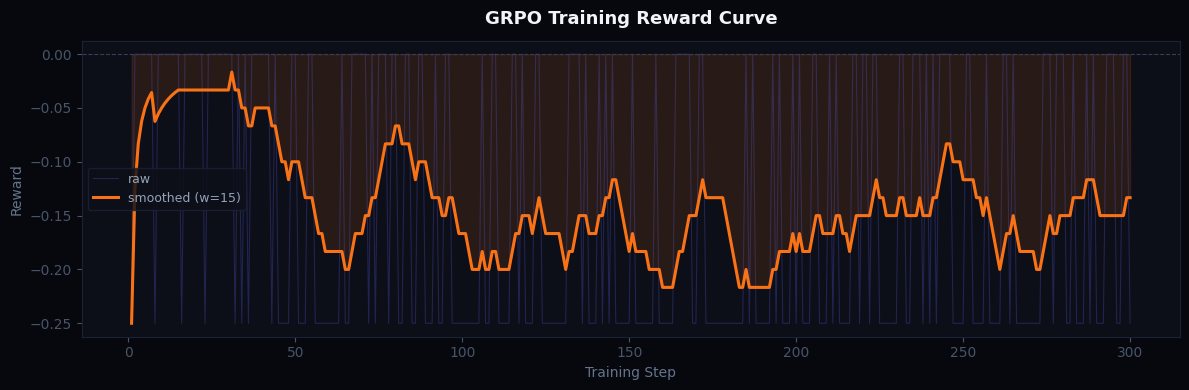

Saved → /content/incident-ops-openenv/outputs/reward_curve.png


In [16]:
# ── Reward Curve ────────────────────────────────────────────────────────
def smooth(values, window=15):
    return pd.Series(values).rolling(window, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(12, 4), facecolor='#07080e')
ax.set_facecolor('#0c0e18')

steps  = df['step'].values if 'step' in df.columns else np.arange(len(df))
reward_col = 'total_reward' if 'total_reward' in df.columns else df.columns[-1]
rewards = df[reward_col].values

ax.plot(steps, rewards,        color='#6366f1', alpha=0.25, linewidth=0.8, label='raw')
ax.plot(steps, smooth(rewards), color='#f97316', linewidth=2.2, label='smoothed (w=15)')
ax.fill_between(steps, smooth(rewards), alpha=0.12, color='#f97316')
ax.axhline(0, color='#334155', linewidth=0.8, linestyle='--')

ax.set_xlabel('Training Step', color='#64748b', fontsize=10)
ax.set_ylabel('Reward',        color='#64748b', fontsize=10)
ax.set_title('GRPO Training Reward Curve', color='#f1f5f9', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(colors='#475569')
ax.spines[:].set_color('#1c2235')
ax.legend(facecolor='#0c0e18', edgecolor='#1c2235', labelcolor='#94a3b8', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/reward_curve.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved → {OUTPUT_DIR}/reward_curve.png')

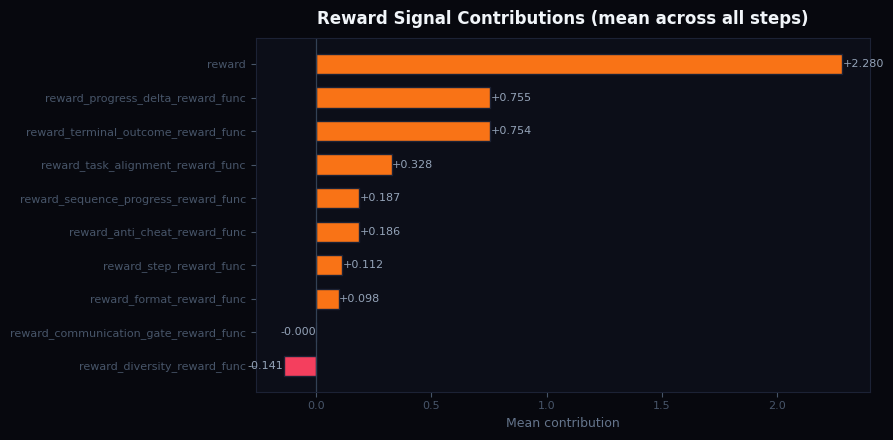

Saved → /content/incident-ops-openenv/outputs/reward_components.png


In [17]:
# ── Reward Component Breakdown ──────────────────────────────────────────
component_cols = [c for c in df.columns
                  if c not in ('step', 'task', 'total_reward', 'episode')
                  and df[c].dtype in (float, 'float64', 'float32')]

if component_cols:
    means = df[component_cols].mean().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(3, len(means) * 0.45)), facecolor='#07080e')
    ax.set_facecolor('#0c0e18')

    colors = ['#f43f5e' if v < 0 else '#f97316' for v in means.values]
    bars   = ax.barh(means.index, means.values, color=colors, height=0.6, edgecolor='#1c2235')

    for bar, val in zip(bars, means.values):
        ax.text(val + 0.002 if val >= 0 else val - 0.002,
                bar.get_y() + bar.get_height() / 2,
                f'{val:+.3f}',
                va='center', ha='left' if val >= 0 else 'right',
                color='#94a3b8', fontsize=8)

    ax.axvline(0, color='#334155', linewidth=0.9)
    ax.set_xlabel('Mean contribution', color='#64748b', fontsize=9)
    ax.set_title('Reward Signal Contributions (mean across all steps)',
                 color='#f1f5f9', fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='#475569', labelsize=8)
    ax.spines[:].set_color('#1c2235')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/reward_components.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved → {OUTPUT_DIR}/reward_components.png')
else:
    print('No per-component columns found in reward_log.csv')
    print('Available columns:', df.columns.tolist())

In [18]:
# ── Per-Task Reward Over Time ────────────────────────────────────────────
if 'task' in df.columns:
    TASK_COLORS = {
        'easy':        '#4ade80',
        'medium':      '#fbbf24',
        'hard':        '#f43f5e',
        'network':     '#38bdf8',
        'memory_leak': '#a78bfa',
        'disk_full':   '#fb923c',
    }

    fig, ax = plt.subplots(figsize=(12, 4), facecolor='#07080e')
    ax.set_facecolor('#0c0e18')

    reward_col = 'total_reward' if 'total_reward' in df.columns else df.columns[-1]

    for task, grp in df.groupby('task'):
        s = grp['step'].values if 'step' in grp.columns else grp.index.values
        r = grp[reward_col].values
        color = TASK_COLORS.get(task, '#94a3b8')
        ax.plot(s, smooth(r), linewidth=1.8, label=task, color=color, alpha=0.9)

    ax.axhline(0, color='#334155', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Step', color='#64748b', fontsize=10)
    ax.set_ylabel('Smoothed Reward', color='#64748b', fontsize=10)
    ax.set_title('Reward Trajectory per Task', color='#f1f5f9', fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='#475569')
    ax.spines[:].set_color('#1c2235')
    ax.legend(facecolor='#0c0e18', edgecolor='#1c2235', labelcolor='#94a3b8',
              fontsize=9, ncol=3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/reward_per_task.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
else:
    print('No task column in log — skipping per-task chart')

No task column in log — skipping per-task chart


## 7️⃣  Save Model + Logs to Google Drive

In [19]:
import pickle, shutil, time

timestamp = time.strftime('%Y%m%d_%H%M')
RUN_DIR   = f'{DRIVE_OUTPUT}/run_{timestamp}'
os.makedirs(RUN_DIR, exist_ok=True)

# 1. Save LoRA adapter weights (safetensors — most portable)
LORA_SAVE = f'{RUN_DIR}/lora_adapter'
model.save_pretrained(LORA_SAVE)
tokenizer.save_pretrained(LORA_SAVE)
print(f'✓ LoRA adapter saved → {LORA_SAVE}')

# 2. Save model config + metadata as pkl
#    (the actual weights stay in safetensors; pkl holds config + training info)
model_meta = {
    'base_model':    MODEL_ID,
    'lora_rank':     LORA_RANK,
    'lora_alpha':    LORA_ALPHA,
    'grpo_steps':    GRPO_MAX_STEPS,
    'num_gens':      NUM_GENERATIONS,
    'timestamp':     timestamp,
    'adapter_path':  LORA_SAVE,   # where to load the actual weights
    'tasks':         ['easy','medium','hard','network','memory_leak','disk_full'],
}

PKL_PATH = f'{RUN_DIR}/model_meta.pkl'
with open(PKL_PATH, 'wb') as f:
    pickle.dump(model_meta, f)
print(f'✓ Metadata pkl → {PKL_PATH}')

# 3. Copy logs + plots to Drive
for fname in ['reward_log.csv', 'reward_curve.png', 'reward_components.png', 'reward_per_task.png']:
    src = f'{OUTPUT_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{RUN_DIR}/{fname}')
        print(f'✓ Copied {fname} → {RUN_DIR}')

print(f'\n✓ All outputs saved to Drive: {RUN_DIR}')
print('\nContents:')
for f in os.listdir(RUN_DIR):
    size = os.path.getsize(f'{RUN_DIR}/{f}') if os.path.isfile(f'{RUN_DIR}/{f}') else '-'
    print(f'  {f:40s}  {size}')

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705/lora_adapter/tokenizer_config.json.


✓ LoRA adapter saved → /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705/lora_adapter
✓ Metadata pkl → /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705/model_meta.pkl
✓ Copied reward_log.csv → /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705
✓ Copied reward_curve.png → /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705
✓ Copied reward_components.png → /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705

✓ All outputs saved to Drive: /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705

Contents:
  lora_adapter                              -
  model_meta.pkl                            308
  reward_log.csv                            48753
  reward_curve.png                          178830
  reward_components.png                     81331


In [ ]:
# Optional: push to Hugging Face Hub
# Add HF_TOKEN to Colab Secrets (key icon in sidebar) first

from google.colab import userdata

try:
    HF_TOKEN   = userdata.get('HF_TOKEN')
    HF_REPO_ID = 'chritsysajii/sre-agent-qwen25-grpo'  # change this

    model.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
    tokenizer.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
    print(f'✓ Pushed to https://huggingface.co/{HF_REPO_ID}')
except Exception as e:
    print(f'HF push skipped: {e}')
    print('To enable: add HF_TOKEN to Colab Secrets (🔑 icon in sidebar)')

## 8️⃣  Before vs After Evaluation (inline)

In [20]:
import json
from unsloth import FastLanguageModel
from env.environment import DevOpsEnv
from graders.grader import compute_score
from tasks.task_config import TASK_CONFIGS
from env.models import VALID_ACTIONS

SYSTEM_PROMPT = (
    'You are an on-call SRE resolving a live infrastructure incident.\n'
    f'Valid actions: {json.dumps(VALID_ACTIONS)}\n'
    'Output ONLY the action name, nothing else.'
)

def run_episode_llm(task, policy_model, policy_tok, max_steps=12):
    FastLanguageModel.for_inference(policy_model)
    env = DevOpsEnv(task=task)
    state = env.reset()
    for _ in range(max_steps):
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': json.dumps(state)},
        ]
        text   = policy_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = policy_tok(text, return_tensors='pt').to(policy_model.device)
        import torch
        with torch.no_grad():
            out = policy_model.generate(**inputs, max_new_tokens=12, do_sample=False)
        decoded = policy_tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip().lower()
        action = next((a for a in VALID_ACTIONS if a in decoded), 'no_op')
        state, _, done, _ = env.step(action)
        if done:
            break
    score, breakdown = compute_score(task, env._state)
    return round(score, 3), bool(env._state.get('resolved', False))

def run_episode_base(task):
    """Heuristic optimal policy as the 'base' comparison."""
    from tasks.task_config import TASK_CONFIGS
    env = DevOpsEnv(task=task)
    env.reset()
    optimal = TASK_CONFIGS[task].get('optimal_actions', [])
    done_acts = set()
    for action in optimal:
        if action not in done_acts:
            _, _, done, _ = env.step(action)
            done_acts.add(action)
            if done: break
    score, _ = compute_score(task, env._state)
    return round(score, 3), bool(env._state.get('resolved', False))

print('Running evaluation across all 6 tasks...')
print('(This uses the TRAINED model loaded in memory)\n')

results = []
tasks   = list(TASK_CONFIGS.keys())

for task in tasks:
    base_score,    base_res    = run_episode_base(task)
    trained_score, trained_res = run_episode_llm(task, model, tokenizer)
    delta = round(trained_score - base_score, 3)
    results.append({
        'task': task,
        'base': base_score, 'base_res': base_res,
        'trained': trained_score, 'trained_res': trained_res,
        'delta': delta,
    })
    print(f'  {task:12s}  base={base_score:.3f}  trained={trained_score:.3f}  '
          f'delta={delta:+.3f}  resolved={trained_res}')

avg_delta = sum(r['delta'] for r in results) / len(results)
resolved  = sum(1 for r in results if r['trained_res'])
print(f'\nAverage delta : {avg_delta:+.3f}')
print(f'Tasks resolved: {resolved}/{len(results)}')

Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running evaluation across all 6 tasks...
(This uses the TRAINED model loaded in memory)



/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12

  easy          base=0.940  trained=0.790  delta=-0.150  resolved=False


Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

...

  network       base=0.960  trained=0.260  delta=-0.700  resolved=False


Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  memory_leak   base=0.930  trained=0.260  delta=-0.670  resolved=False


Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  disk_full     base=0.920  trained=0.490  delta=-0.430  resolved=False

Average delta : -0.465
Tasks resolved: 0/6


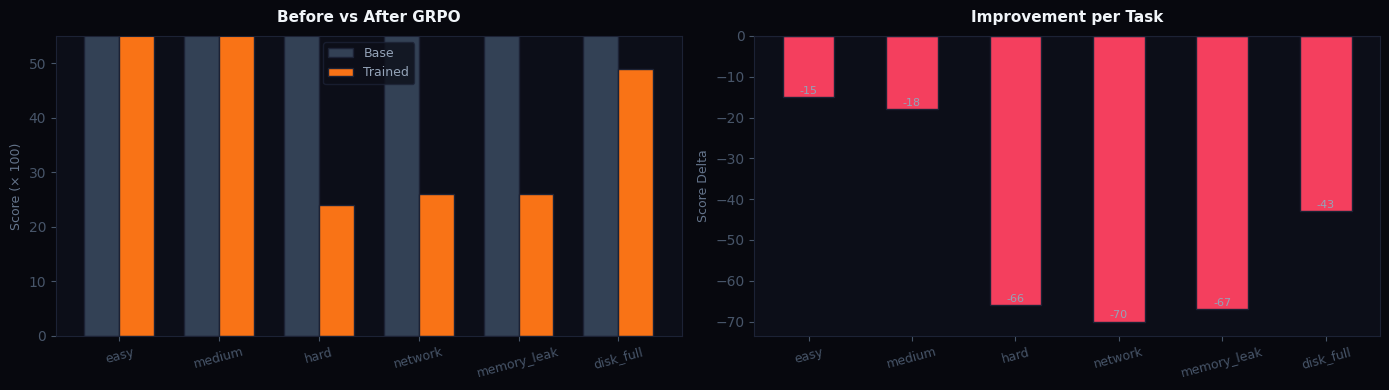

Saved → /content/drive/MyDrive/incident_ops_outputs/run_20260611_0705/before_after.png


In [21]:
# ── Before vs After chart ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

tasks_l   = [r['task'] for r in results]
base_s    = [r['base'] * 100 for r in results]
trained_s = [r['trained'] * 100 for r in results]
deltas    = [r['delta'] * 100 for r in results]

x   = np.arange(len(tasks_l))
w   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#07080e')

# Left — grouped bar chart
ax = axes[0]
ax.set_facecolor('#0c0e18')
ax.bar(x - w/2, base_s,    w, label='Base',    color='#334155', edgecolor='#1c2235')
ax.bar(x + w/2, trained_s, w, label='Trained', color='#f97316', edgecolor='#1c2235')
ax.set_xticks(x)
ax.set_xticklabels(tasks_l, color='#94a3b8', fontsize=9, rotation=15)
ax.set_ylabel('Score (× 100)', color='#64748b', fontsize=9)
ax.set_title('Before vs After GRPO', color='#f1f5f9', fontsize=11, fontweight='bold', pad=10)
ax.tick_params(colors='#475569')
ax.spines[:].set_color('#1c2235')
ax.legend(facecolor='#0c0e18', edgecolor='#1c2235', labelcolor='#94a3b8', fontsize=9)
ax.set_ylim(0, 55)

# Right — delta bar chart
ax2 = axes[1]
ax2.set_facecolor('#0c0e18')
colors = ['#4ade80' if d >= 0 else '#f43f5e' for d in deltas]
bars   = ax2.bar(x, deltas, color=colors, edgecolor='#1c2235', width=0.5)
for bar, d in zip(bars, deltas):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{d:+.0f}', ha='center', va='bottom', color='#94a3b8', fontsize=8)
ax2.axhline(0, color='#334155', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(tasks_l, color='#94a3b8', fontsize=9, rotation=15)
ax2.set_ylabel('Score Delta', color='#64748b', fontsize=9)
ax2.set_title('Improvement per Task', color='#f1f5f9', fontsize=11, fontweight='bold', pad=10)
ax2.tick_params(colors='#475569')
ax2.spines[:].set_color('#1c2235')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/before_after.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
shutil.copy(f'{OUTPUT_DIR}/before_after.png', f'{RUN_DIR}/before_after.png')
plt.show()
print(f'Saved → {RUN_DIR}/before_after.png')

## 9️⃣  How to Test Locally

After training, download your Drive folder `incident_ops_outputs/run_<timestamp>/` to:
```
c:\Users\chris\college\programming\project\devops-openenv\outputs\run_<timestamp>\
```

Then test locally:

```bash
# 1. Read the metadata pkl to get the adapter path
python - <<'EOF'
import pickle
with open('outputs/run_<timestamp>/model_meta.pkl', 'rb') as f:
    meta = pickle.load(f)
print(meta)
EOF

# 2. Run multi-seed evaluation
python scripts/evaluate.py \
    --trained-model outputs/run_<timestamp>/lora_adapter \
    --n-seeds 5 \
    --label grpo_v1

# 3. Start the server with the trained model
TRAINED_MODEL=outputs/run_<timestamp>/lora_adapter uvicorn app:app --port 7860
```

Or open `http://localhost:7860` and click **⚡ Auto-Solve (AI Demo)** to watch the agent live.